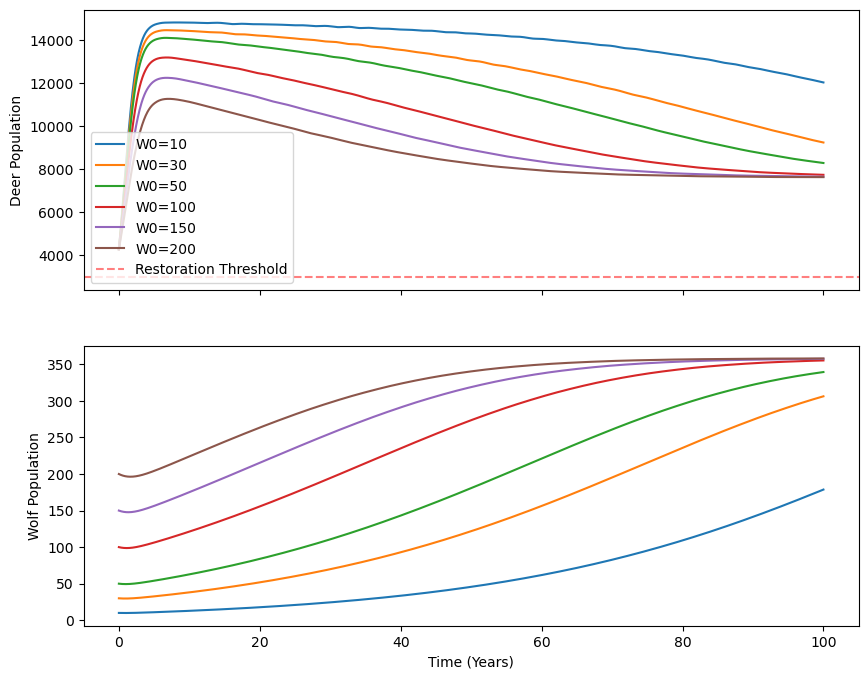

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE system with Holling Type II & Logistic Growth
def wolf_deer_holling(t, y, params):
    D, W = y
    r, e, beta, d, h, K = params
    
    # Holling Type II functional response
    predation = (e * D * W) / (1 + h * e * D)
    
    # Logistic growth for deer + predation
    dDdt = r * D * (1 - D/K) - predation
    
    # Wolf growth based on saturated consumption
    dWdt = beta * predation - d * W
    
    return [dDdt, dWdt]

def simulate_holling(params, D0, W0, t_max=100):
    t_eval = np.linspace(0, t_max, 2000)
    sol = solve_ivp(wolf_deer_holling, [0, t_max], [D0, W0], 
                    args=(params,), t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1]

# --- Parameters ---
r = 1.138      # deer birth rate
e = 17/7000    # attack rate
beta = 0.006   # conversion efficiency
d = 1/14       # wolf death rate
h = 0.03       # handling time 
K = 15000      # deer carrying capacity 

params = (r, e, beta, d, h, K)

# Initial populations
D0 = 4284
W0_values = [10, 30, 50, 100, 150, 200] 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for W0 in W0_values:
    t, D, W = simulate_holling(params, D0, W0)
    ax1.plot(t, D, label=f"W0={W0}")
    ax2.plot(t, W, label=f"W0={W0}")

ax1.axhline(3000, color='red', linestyle='--', alpha=0.5, label="Restoration Threshold")
ax1.set_ylabel("Deer Population")
ax1.legend()
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Wolf Population")
plt.show()